# Exploratory Data Analysis
Tujuan: Menganalisis pola dan perilaku pada data untuk menjawab beberapa pertanyaan.

## 1. Data Loading
Pertama, kita perlu mengambil dan melihat data. Saat ini, kita sudah bisa menggunakan data yang telah diproses pada notebook sebelumnya.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("../data/interim/results_clean.csv", parse_dates=["date"])

### Preview Dataset

In [3]:
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 2. Dataset Overview

Kita akan mulai dengan mengenali dataset kita.

### Pertanyaan 1:
**Seberapa besar dataset yang kita analisis?**

In [4]:
print(f"Jumlah baris : {results.shape[0]:,}")
print(f"Jumlah kolom : {results.shape[1]}")

Jumlah baris : 49,433
Jumlah kolom : 9


### Insight 1:
Dataset ini memiliki lebih dari 49 ribu hasil pertandingan internasional dengan berbagai atribut penting seperti tanggal pertandingan, tim, skor, turnamen, dan lokasi. Jumlah observasi yang besar memberikan landasan yang kuat untuk pemodelan Machine Learning. Langkah berikutnya adalah memahami distribusi karakteristik data, terutama keseimbangan kelas hasil pertandingan.

### Pertanyaan 2: 
**Bagaimana rentang waktu dataset ini?**

In [5]:
print(f"Tanggal pertama: {results['date'].min()}")
print(f"Tanggal terakhir: {results['date'].max()}")

Tanggal pertama: 1872-11-30 00:00:00
Tanggal terakhir: 2026-06-18 00:00:00


### Insight 2:
Rentang waktu 154 tahun (1872–2026) tidak hanya menunjukkan kekayaan sejarah, tetapi juga memberikan tantangan analitis. Aturan, taktik, dan intensitas sepak bola telah berevolusi secara drastis; pola historis di awal abad ke-20 mungkin tidak lagi relevan dengan dinamika sepak bola modern. Untuk pemodelan, kita dapat mempertimbangkan untuk membatasi rentang waktu pelatihan atau melakukan analisis per era apabila ditemukan perubahan pola yang signifikan.

### Pertanyaan 3: 
**Berapa banyak tim unik?**

In [6]:
teams = pd.concat([
    results["home_team"],
    results["away_team"]
])

print(f"Banyak tim berbeda: {teams.nunique()}")

Banyak tim berbeda: 336


### Insight 3:
Dataset memuat 336 entitas tim yang berbeda, jumlah yang melebihi keanggotaan FIFA saat ini. Hal ini mencerminkan perubahan geopolitik sepanjang sejarah, seperti pemecahan negara maupun pergantian nama negara. Oleh karena itu, proses standardisasi nama tim akan menjadi langkah penting pada tahap feature engineering.

### Pertanyaan 4: 
**Berapa banyak jenis turnamen?**

In [7]:
print(results["tournament"].nunique())

200


In [8]:
results["tournament"].value_counts().head(10)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            992
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
Name: count, dtype: int64

### Insight 4
Dataset ini merangkum 200 variasi turnamen, yang didominasi oleh Friendly Match dan babak kualifikasi. Tingkat kompetisi sangat memengaruhi hasil laga, tim besar cenderung merotasi pemain dan tampil kurang maksimal di laga persahabatan dibandingkan saat bermain di Piala Dunia. Salah satu pendekatan yang layak dieksplorasi adalah mengelompokkan turnamen berdasarkan tingkat prestise agar model lebih mudah menangkap konteks pertandingan.

### Implikasi untuk Tahap Berikutnya

Secara keseluruhan, eksplorasi awal ini memberikan kita gambaran yang kuat mengenai kondisi data dan apa yang perlu dilakukan sebelum data ini siap masuk ke tahap permodelan. Berikut adalah ringkasan dari temuan kita:

| Pertanyaan | Temuan Faktual (Nominal) | Insight & Tindakan Lanjutan (*Action Plan*) |
|---|---|---|
| **Seberapa besar dataset yang dianalisis?** | **> 49.000 baris** dengan beberapa kolom atribut. | Volume data sangat mumpuni untuk prediksi ML. Bisa cek distribusi kelas (*class imbalance*) dari hasil akhir laga. |
| **Bagaimana rentang waktu dataset ini?** | **154 tahun** (1872 - 2026). | Pola lama mungkin *outdated*. Butuh pembagian data latih-uji secara kronologis (*time-based split*) dan clustering era. |
| **Berapa banyak tim unik?** | **336 tim** berbeda. | Melebihi batas keanggotaan FIFA, butuh pemetaan sejarah geopolitik/perubahan nama negara. |
| **Berapa banyak jenis turnamen?** | **200 variasi** turnamen. | Gengsi kompetisi memengaruhi hasil laga. Pendekatan yang layak dieksplorasi adalah mengelompokkan turnamen berdasarkan tingkat prestise agar model lebih mudah menangkap konteks pertandingan. |

## 3. Match Distribution
Kita akan melihat perkembangan sepak bola internasional dari waktu ke waktu dan perbedaan era dalam sepakbola.

### Pertanyaan 1
**Berapa banyak pertandingan yang dimainkan setiap tahun?**

In [9]:
# jumlah pertandingan setiap tahun
matches_per_year = (
    results
    .groupby(results["date"].dt.year)
    .size()
)

matches_per_year.head()

date
1872    1
1873    1
1874    1
1875    1
1876    2
dtype: int64

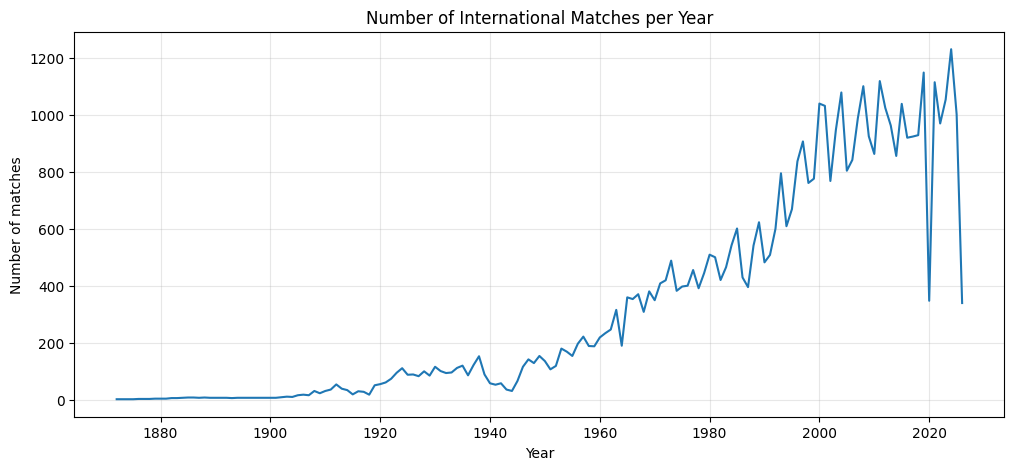

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    matches_per_year.index,
    matches_per_year.values
)

plt.title("Grafik 1: Number of International Matches per Year")
plt.xlabel("Year")
plt.ylabel("Number of matches")

plt.grid(alpha=0.3)

plt.show()


### Analisis Grafik 1: Number of International Matches per Year

Sepakbola internasional menunjukkan perkembangan pesat pada beberapa era dan penurunan pada beberapa tahun pula. Terdapat beberapa hal yang menyebabkan naik turunnya jumlah pertandingan internasional, seperti Perang Dunia dan pandemi.

Grafik garis (*line chart*) di atas menyajikan data *time-series* mengenai jumlah pertandingan sepak bola internasional yang tercatat dari tahun 1872 hingga tahun 2026. Sumbu **X (horizontal)** mewakili tahun, sedangkan sumbu **Y (vertikal)** menunjukkan total frekuensi pertandingan pada tahun tersebut.

#### Ringkasan per Era

| Era / Periode | Karakteristik Tren Grafik | Faktor Penyebab & Konteks Sejarah |
| :--- | :--- | :--- |
| **Pra-1914** *(Awal Mula)* | Garis sangat landai dan berada di dekat angka 0. | Sepak bola internasional baru lahir dan hanya dimainkan secara terbatas (mayoritas di wilayah Britania Raya dan Eropa Barat). |
| **1914–1945** *(Era Perang)* | Terjadi fluktuasi kecil dengan dua penurunan (*drop*) yang nyata. | Aktivitas olahraga global terhenti akibat **Perang Dunia I (1914–1918)** dan **Perang Dunia II (1939–1945)**. |
| **1950–2000** *(Ekspansi Global)* | Tren naik secara eksponensial dan sangat curam. | Terjadinya dekolonisasi (banyak negara baru merdeka), meluasnya keanggotaan FIFA, kemudahan transportasi udara, dan komersialisasi media. |
| **2000–2019** *(Era Modern)* | Jumlah pertandingan berada di puncaknya (800–1200+), namun membentuk pola *zigzag* yang konsisten. | Pola siklikal akibat kalender turnamen 4-tahunan (Piala Dunia, Euro, Copa America) dan fase kualifikasinya. |
| **~2020** *(Pandemi)* | Penurunan vertikal yang sangat ekstrem (anjlok ke kisaran 300-400 pertandingan). | Dampak langsung dari pandemik **COVID-19** yang memicu *lockdown* global dan pembatalan seluruh kalender FIFA. |
| **Pasca-2020** *(Rebound & Ujung Data)* | Lonjakan tajam melebihi 1200 pertandingan, diikuti penurunan di titik akhir. | Efek kompensasi jadwal kualifikasi yang tertunda dipadatkan pada 2021/2022. Penurunan di ujung kanan disebabkan oleh *incomplete data* (tahun berjalan). |

#### Pola Era Modern
Memasuki abad ke-21, grafik tidak lagi naik secara linear melainkan membentuk pola gigi gergaji (*zigzag*). Ini adalah karakteristik khas data *time-series* olahraga:
* **Puncak (Peaks):** Pola ini kemungkinan besar dipengaruhi oleh siklus penyelenggaraan turnamen internasional dan fase kualifikasinya seperti UEFA, CONMEBOL, AFC, dll. yang menggelar banyak pertandingan dalam waktu berdekatan.
* **Lembah (Troughs):** Terjadi pada tahun pelaksanaan turnamen utama atau tepat setelah turnamen selesai, di mana intensitas pertandingan kualifikasi mereda dan digantikan oleh jeda kompetisi.

#### Outlier Ekstrem (Tahun 2020)
Titik anjlok mendekati angka 300 pada tahun 2020 merupakan sebuah *outlier* struktural. Tahun 2020 tampak sebagai salah satu outlier paling mencolok dalam keseluruhan dataset, yang sangat mungkin berkaitan dengan pandemi COVID-19 dan penghentian sementara berbagai kompetisi internasional.


### Insight 1

**Volume Pertandingan Mencapai 800–1.200+ per Tahun di Era Modern**. Jumlah pertandingan sepak bola internasional menunjukkan tren pertumbuhan yang sangat pesat sejak dekade 1950-an hingga **mencapai puncaknya pada era modern (pasca-2000)**. Pada periode ini, jumlah pertandingan tahunan umumnya berada pada kisaran 800 hingga lebih dari 1.200 pertandingan. Meskipun demikian, pola tersebut tidak bersifat konstan karena dipengaruhi oleh siklus kalender kompetisi internasional, serta dapat mengalami penurunan tajam akibat peristiwa global seperti perang dunia maupun pandemi COVID-19.

### Pertanyaan 2
**Dekade mana yang paling aktif?**

In [12]:
results["decade"] = (
    results["date"].dt.year // 10
) * 10

matches_per_decade = (
    results
    .groupby("decade")
    .size()
)

matches_per_decade

decade
1870      13
1880      55
1890      59
1900     138
1910     330
1920     831
1930    1079
1940     833
1950    1651
1960    2971
1970    4133
1980    5025
1990    6944
2000    9526
2010    9787
2020    6058
dtype: int64

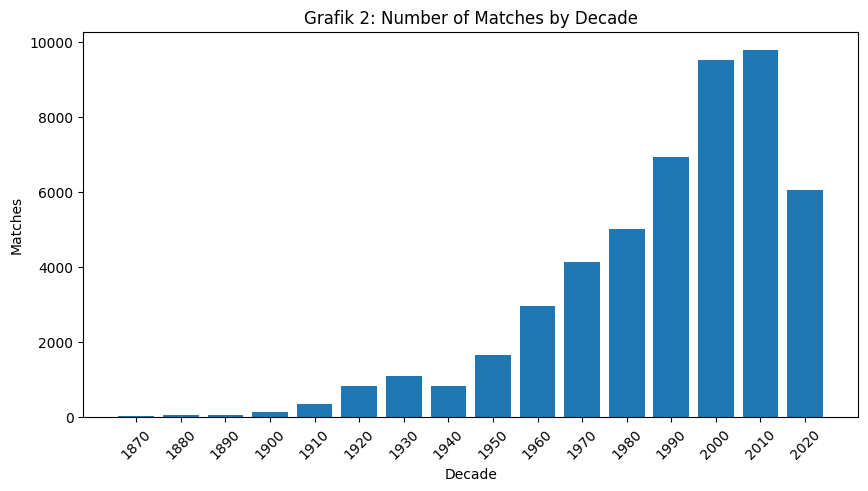

In [13]:
plt.figure(figsize=(10,5))

plt.bar(
    matches_per_decade.index.astype(str),
    matches_per_decade.values
)

plt.xticks(rotation=45)

plt.title("Grafik 2: Number of Matches by Decade")
plt.xlabel("Decade")
plt.ylabel("Matches")

plt.show()

### Analisis Grafik 2: Number of Matches by Decade

Visualisasi ini menggunakan grafik batang (*bar chart*) yang mengagregasi data tahunan menjadi periode 10 tahunan. Berbeda dengan grafik garis tahunan yang penuh fluktuasi (*zigzag*), visualisasi per dekade ini sangat efektif untuk menghilangkan *noise* musiman (seperti siklus kualifikasi) dan memperlihatkan **tren pertumbuhan** secara jernih.

#### Ringkasan per Era

| Dekade / Periode | Total Pertandingan | Karakteristik Tren & Konteks Sejarah |
| :--- | :--- | :--- |
| **1870 – 1900** | 13 hingga 138 | Sepak bola internasional baru lahir. Pertumbuhan sangat lambat dan mayoritas pertandingan hanya terjadi secara regional di daratan Britania Raya. |
| **1910 – 1930** | 330 hingga 1.079 | Terjadi lonjakan signifikan hingga menembus angka 1.000 pada tahun 1930. Ini didorong oleh penyelenggaraan turnamen besar pertama seperti Copa America dan Piala Dunia edisi perdana (1930). |
| **1940** | 833 | Terjadi **penurunan tajam** (turun sekitar 22% dari dekade sebelumnya). Mayoritas liga dan aktivitas lintas negara dihentikan total selama paruh pertama dekade ini akibat perang. |
| **1950 – 2010** | 1.651 hingga 9.787 | Tren naik tanpa putus yang sangat masif di setiap dekadenya. Ini adalah hasil dari gelombang dekolonisasi (munculnya negara-negara baru yang bergabung dengan FIFA), revolusi transportasi udara yang mempermudah laga *away* lintas benua, serta komersialisasi hak siar televisi. |
| **2010** | **9.787** | Sepak bola modern mencapai kapasitas puncaknya. Munculnya kompetisi format baru seperti *UEFA Nations League* dan jeda internasional yang sangat padat memaksimalkan jumlah pertandingan di dekade ini. |
| **2020** | 6.058 *(sementara)* | Angka ini turun drastis, namun **bukan** berarti tren sepak bola menurun. Ada dua penyebab: (1) Pandemi COVID-19 di tahun 2020 membekukan nyaris seluruh kalender FIFA, dan (2) Kita saat ini masih berada di pertengahan dekade 2020-an, sehingga data ini adalah data yang belum selesai (*incomplete data*). |

#### Insight Tambahan

Data agregasi ini memberikan *insight* fundamental mengenai perbandingan dua peristiwa gangguan global terbesar:

* **Perang Dunia II vs Pandemi:** Pada grafik tahunan (sebelumnya), anjlokan akibat COVID-19 di tahun 2020 terlihat jauh lebih ekstrem dan curam dibandingkan Perang Dunia II. Namun, ketika data diagregasi per dekade, **efek Perang Dunia II (1940) justru terlihat lebih menonjol** sebagai satu-satunya dekade historis yang mengalami *negative growth* atau penurunan secara komulatif. Ini menunjukkan bahwa meskipun COVID-19 menghentikan aktivitas secara total sesaat, durasi gangguan Perang Dunia II memakan porsi waktu bertahun-tahun yang dampaknya lebih besar secara akumulasi dekade. 

* **Proyeksi Dekade 2020:** Jika data dekade 2020 saat ini sudah mencapai 6.058 (di pertengahan dekade), dan format kompetisi baru (seperti Piala Dunia 2026 yang diperluas menjadi 48 tim) mulai diterapkan.  Sehingga dekade 2020 masih berpotensi melampaui dekade sebelumnya setelah seluruh data pada dekade tersebut lengkap.


### Insight 2
Dekade 2010–2019 menjadi periode paling aktif dalam sejarah sepak bola internasional dengan total 9.787 pertandingan. Temuan ini menunjukkan bahwa sebelum gangguan pandemi COVID-19, kalender pertandingan internasional telah mencapai tingkat kepadatan tertinggi sepanjang sejarah, didukung oleh bertambahnya jumlah kompetisi dan semakin padatnya agenda FIFA.

### Pertanyaan 3
**Berapa pertandingan sebelum dan sesudah 1950?**

In [14]:
before_1950 = (
    results["date"].dt.year < 1950
).sum()

after_1950 = (
    results["date"].dt.year >= 1950
).sum()

print(f"Pertandingan sebelum tahun 1950: {before_1950} pertandingan")
print(f"Pertandingan sesudah tahun 1950: {after_1950} pertandingan")

Pertandingan sebelum tahun 1950: 3338 pertandingan
Pertandingan sesudah tahun 1950: 46095 pertandingan


### Insight 3
Sebagian besar pertandingan dalam dataset berasal dari periode setelah tahun 1950. Hal ini menunjukkan bahwa sepak bola internasional mengalami ekspansi yang sangat pesat pada era modern, seiring bertambahnya jumlah negara yang berpartisipasi, berkembangnya kompetisi internasional, serta meningkatnya frekuensi pertandingan. Temuan ini juga mengindikasikan bahwa model prediksi nantinya akan lebih banyak belajar dari karakteristik sepak bola modern dibandingkan era awal perkembangan olahraga ini.

### Final Insight
Analisis distribusi pertandingan menunjukkan bahwa perkembangan sepak bola internasional sangat dipengaruhi oleh dinamika sejarah dunia. Jumlah pertandingan meningkat secara konsisten sejak pertengahan abad ke-20 seiring globalisasi sepak bola, namun tetap menunjukkan penurunan pada periode gangguan global seperti Perang Dunia maupun pandemi COVID-19. Selain itu, pola siklikal pada era modern mengindikasikan adanya pengaruh kalender kompetisi internasional terhadap frekuensi pertandingan tahunan. Temuan-temuan ini memberikan konteks penting bahwa waktu bukan sekadar atribut tanggal, melainkan representasi perubahan struktur kompetisi sepak bola sepanjang sejarah. Oleh karena itu, aspek temporal perlu dipertimbangkan pada tahap feature engineering maupun evaluasi model.